# Mencari akar dengan Bisection dan Newton–Raphson

Fungsi yang dicari akarnya adalah

$$f(x) = e^{-0.5x}\cos(3x) - 0.2.$$

Notebook ini mempertahankan perhitungan dari `cb11.py`, lalu memperlihatkan bentuk fungsi, langkah kedua metode, dan laju konvergensinya. Jalankan sel dari atas ke bawah. Paket yang diperlukan: `sympy`, `numpy`, dan `matplotlib`.


In [29]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x = sp.symbols('x')
f_expr = sp.exp(-sp.Rational(1, 2) * x) * sp.cos(3 * x) - sp.Rational(1, 5)
df_expr = sp.diff(f_expr, x)

# Fungsi skalar untuk iterasi dan fungsi vektor untuk grafik.
f = sp.lambdify(x, f_expr, 'math')
df = sp.lambdify(x, df_expr, 'math')
f_plot = sp.lambdify(x, f_expr, 'numpy')
df_plot = sp.lambdify(x, df_expr, 'numpy')

print('f(x)  =', f_expr)
print("f'(x) =", df_expr)


f(x)  = -1/5 + exp(-x/2)*cos(3*x)
f'(x) = -3*exp(-x/2)*sin(3*x) - exp(-x/2)*cos(3*x)/2


## 1. Bentuk fungsi dan turunannya

Titik potong kurva $f(x)$ dengan sumbu mendatar adalah akar yang dicari. Turunan $f'(x)$ menentukan kemiringan garis singgung pada metode Newton–Raphson.


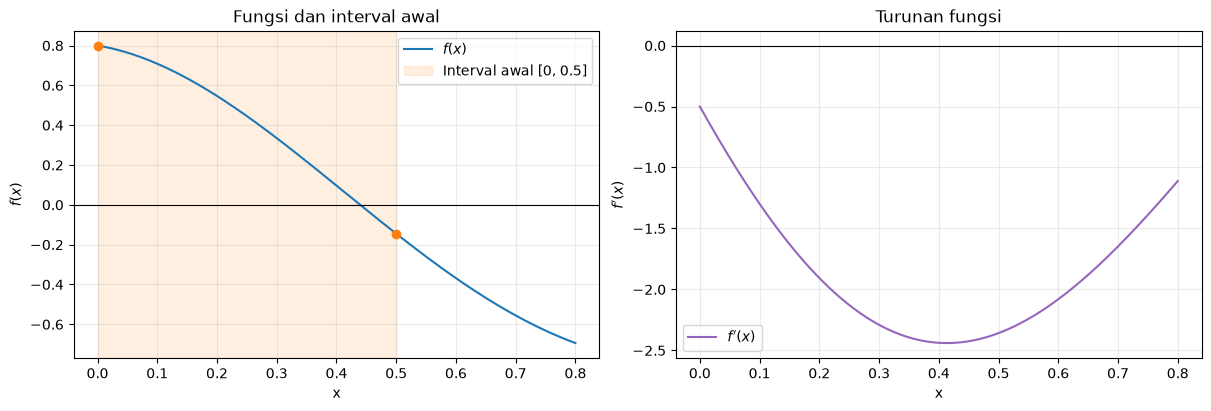

In [30]:
xs = np.linspace(0, 0.8, 500)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(xs, f_plot(xs), color='tab:blue', label='$f(x)$')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvspan(0, 0.5, color='tab:orange', alpha=0.12, label='Interval awal [0, 0.5]')
axes[0].scatter([0, 0.5], [f(0), f(0.5)], color='tab:orange', zorder=3)
axes[0].set(xlabel='x', ylabel='$f(x)$', title='Fungsi dan interval awal')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(xs, df_plot(xs), color='tab:purple', label="$f'(x)$")
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set(xlabel='x', ylabel="$f'(x)$", title='Turunan fungsi')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.show()


## 2. Menghitung akar dan menyimpan riwayat iterasi

Bisection membagi dua interval yang mengurung akar. Newton–Raphson memakai garis singgung pada tebakan saat ini untuk menghasilkan tebakan berikutnya. Riwayat iterasi disimpan agar prosesnya dapat digambar.


In [31]:
def bisection(a, b, tol=1e-6, max_iter=100):
    if not a < b:
        raise ValueError('Harus memenuhi a < b.')
    if f(a) * f(b) >= 0:
        raise ValueError('f(a) dan f(b) harus berbeda tanda.')

    history = []
    for i in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)
        error = (b - a) / 2
        history.append({'iter': i, 'a': a, 'b': b, 'c': c,
                        'fc': fc, 'error': error})

        if error < tol or abs(fc) < tol:
            return c, history
        if f(a) * fc < 0:
            b = c
        else:
            a = c

    raise RuntimeError('Bisection tidak konvergen dalam batas iterasi.')


def newton_raphson(x0, tol=1e-6, max_iter=100):
    history = []
    x_now = x0
    for i in range(1, max_iter + 1):
        fx = f(x_now)
        dfx = df(x_now)
        if abs(dfx) < 1e-12:
            raise ZeroDivisionError('Turunan terlalu dekat dengan nol.')

        x_next = x_now - fx / dfx
        error = abs(x_next - x_now)
        history.append({'iter': i, 'x_now': x_now, 'fx': fx,
                        'dfx': dfx, 'x_next': x_next, 'error': error})

        if error < tol:
            return x_next, history
        x_now = x_next

    raise RuntimeError('Newton–Raphson tidak konvergen dalam batas iterasi.')


akar_b, riwayat_b = bisection(a=0.0, b=0.5, tol=1e-6)
akar_n, riwayat_n = newton_raphson(x0=0.4, tol=1e-6)

print('BISECTION')
print(f"{'Iter':>4} {'a':>11} {'b':>11} {'c':>11} {'f(c)':>13} {'Galat':>13}")
for r in riwayat_b:
    print(f"{r['iter']:4d} {r['a']:11.6f} {r['b']:11.6f} {r['c']:11.6f} "
          f"{r['fc']:13.6e} {r['error']:13.6e}")
print(f'Konvergen pada iterasi ke-{len(riwayat_b)}; akar ≈ {akar_b:.6f}\n')

print('NEWTON–RAPHSON')
print(f"{'Iter':>4} {'x_n':>11} {'f(x_n)':>13} {'turunan':>13} {'x_n+1':>11} {'Galat':>13}")
for r in riwayat_n:
    print(f"{r['iter']:4d} {r['x_now']:11.6f} {r['fx']:13.6e} "
          f"{r['dfx']:13.6e} {r['x_next']:11.6f} {r['error']:13.6e}")
print(f'Konvergen pada iterasi ke-{len(riwayat_n)}; akar ≈ {akar_n:.6f}')


BISECTION
Iter           a           b           c          f(c)         Galat
   1    0.000000    0.500000    0.250000  4.457132e-01  2.500000e-01
   2    0.250000    0.500000    0.375000  1.574579e-01  1.250000e-01
   3    0.375000    0.500000    0.437500  5.246798e-03  6.250000e-02
   4    0.437500    0.500000    0.468750 -7.041974e-02  3.125000e-02
   5    0.437500    0.468750    0.453125 -3.269316e-02  1.562500e-02
   6    0.437500    0.453125    0.445312 -1.374471e-02  7.812500e-03
   7    0.437500    0.445312    0.441406 -4.253687e-03  3.906250e-03
   8    0.437500    0.441406    0.439453  4.954537e-04  1.953125e-03
   9    0.439453    0.441406    0.440430 -1.879402e-03  9.765625e-04
  10    0.439453    0.440430    0.439941 -6.920445e-04  4.882812e-04
  11    0.439453    0.439941    0.439697 -9.831275e-05  2.441406e-04
  12    0.439453    0.439697    0.439575  1.985662e-04  1.220703e-04
  13    0.439575    0.439697    0.439636  5.012562e-05  6.103516e-05
  14    0.439636    0.43

### Visualisasi setiap iterasi

Jalankan dua sel berikut setelah tabel. Gunakan tombol **Play**, **Pause**, atau penggeser di bawah grafik untuk melihat satu iterasi tertentu.


In [32]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

fig, ax = plt.subplots(figsize=(8, 4.5))
xs_b = np.linspace(0, 1, 500)
ys_b = f_plot(xs_b)

def gambar_bisection(frame):
    r = riwayat_b[frame]
    ax.clear()
    ax.plot(xs_b, ys_b, color='tab:blue', label='$f(x)$')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvspan(r['a'], r['b'], color='tab:orange', alpha=0.22,
               label='Interval saat ini')
    ax.scatter([r['a'], r['b']], [f(r['a']), f(r['b'])],
               color='tab:orange', s=55, zorder=3, label='Ujung interval')
    ax.scatter(r['c'], r['fc'], color='tab:red', s=65, zorder=4,
               label='Titik tengah c')
    ax.plot([r['c'], r['c']], [0, r['fc']], color='tab:red',
            linestyle=':', linewidth=1)
    ax.set(xlim=(0, 1), ylim=(-0.85, 0.85), xlabel='x', ylabel='$f(x)$',
           title=(f"Bisection · iterasi {r['iter']}/{len(riwayat_b)} · "
                  f"c = {r['c']:.6f} · galat ≤ {r['error']:.2e}"))
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right')

anim_b = FuncAnimation(fig, gambar_bisection, frames=len(riwayat_b),
                       interval=900, repeat=False)
display(HTML(anim_b.to_jshtml(fps=5)))
plt.close(fig)


In [33]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xs_n = np.linspace(0, 1, 500)

def gambar_newton(frame):
    r = riwayat_n[frame]
    ax.clear()
    ax.plot(xs_n, f_plot(xs_n), color='tab:blue', label='$f(x)$')
    ax.axhline(0, color='black', linewidth=0.8)
    garis_singgung = r['fx'] + r['dfx'] * (xs_n - r['x_now'])
    ax.plot(xs_n, garis_singgung, '--', color='tab:orange',
            label='Garis singgung pada $x_n$')
    ax.scatter(r['x_now'], r['fx'], color='tab:red', s=65,
               zorder=4, label='$x_n$ pada kurva')
    ax.scatter(r['x_next'], 0, color='tab:green', s=65,
               zorder=4, label='$x_{n+1}$ pada sumbu x')
    ax.plot([r['x_now'], r['x_now']], [0, r['fx']],
            color='tab:red', linestyle=':', linewidth=1)
    ax.set(xlim=(0, 1), ylim=(-0.85, 0.85), xlabel='x', ylabel='y',
           title=(f"Newton–Raphson · iterasi {r['iter']}/{len(riwayat_n)} · "
                  f"xₙ = {r['x_now']:.6f} → xₙ₊₁ = {r['x_next']:.6f}"))
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right')

anim_n = FuncAnimation(fig, gambar_newton, frames=len(riwayat_n),
                       interval=1400, repeat=False)
display(HTML(anim_n.to_jshtml(fps=1)))
plt.close(fig)


## 3. Cara setiap metode mendekati akar

Di kiri, setiap garis mendatar menunjukkan interval Bisection pada iterasi tersebut; titik menandai titik tengahnya. Di kanan, garis putus putus adalah garis singgung Newton–Raphson pada beberapa iterasi pertama. Perpotongannya dengan sumbu $x$ menjadi tebakan berikutnya.


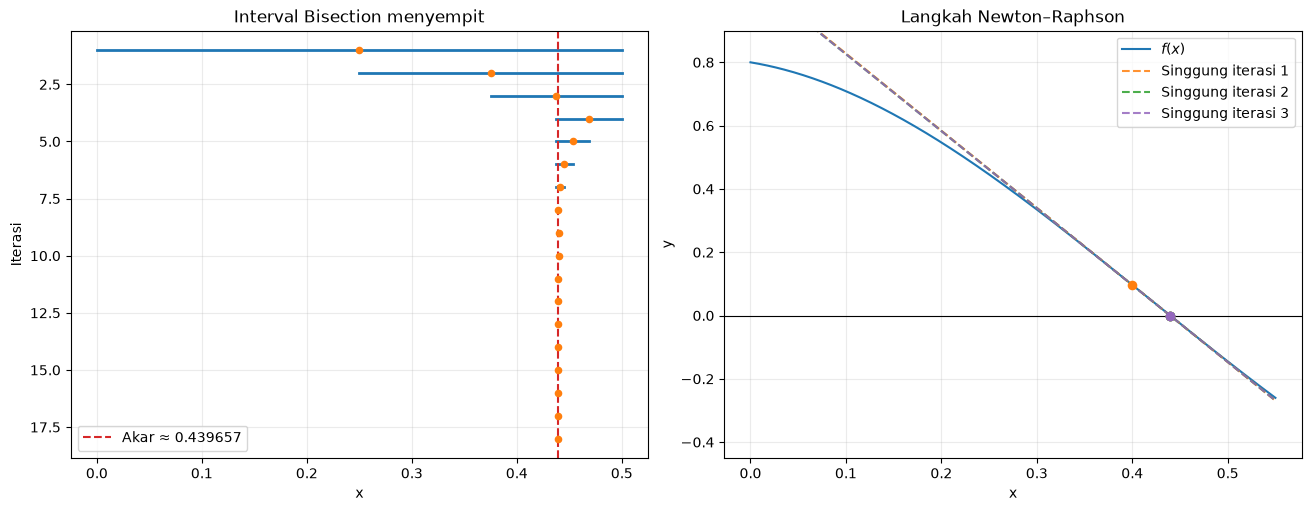

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

for r in riwayat_b:
    y = r['iter']
    axes[0].plot([r['a'], r['b']], [y, y], color='tab:blue', linewidth=2)
    axes[0].scatter(r['c'], y, color='tab:orange', s=20, zorder=3)
axes[0].axvline(akar_b, color='tab:red', linestyle='--', label=f'Akar ≈ {akar_b:.6f}')
axes[0].invert_yaxis()
axes[0].set(xlabel='x', ylabel='Iterasi', title='Interval Bisection menyempit')
axes[0].grid(alpha=0.25)
axes[0].legend()

xs = np.linspace(0, 0.55, 500)
axes[1].plot(xs, f_plot(xs), color='tab:blue', label='$f(x)$')
axes[1].axhline(0, color='black', linewidth=0.8)
colors = ['tab:orange', 'tab:green', 'tab:purple']
for r, color in zip(riwayat_n[:3], colors):
    tangent = r['fx'] + r['dfx'] * (xs - r['x_now'])
    axes[1].plot(xs, tangent, '--', color=color, alpha=0.85,
                 label=f"Singgung iterasi {r['iter']}")
    axes[1].scatter([r['x_now'], r['x_next']], [r['fx'], 0],
                    color=color, s=35, zorder=3)
axes[1].set(xlabel='x', ylabel='y', title='Langkah Newton–Raphson', ylim=(-0.45, 0.9))
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.show()


## 4. Perbandingan konvergensi

Galat Bisection adalah setengah lebar interval, yaitu batas atas galat akar. Galat Newton–Raphson di sini adalah selisih dua tebakan berurutan. Karena definisinya berbeda, grafik ini menunjukkan laju penurunan ukuran langkah masing masing metode, bukan perbandingan galat absolut yang identik.


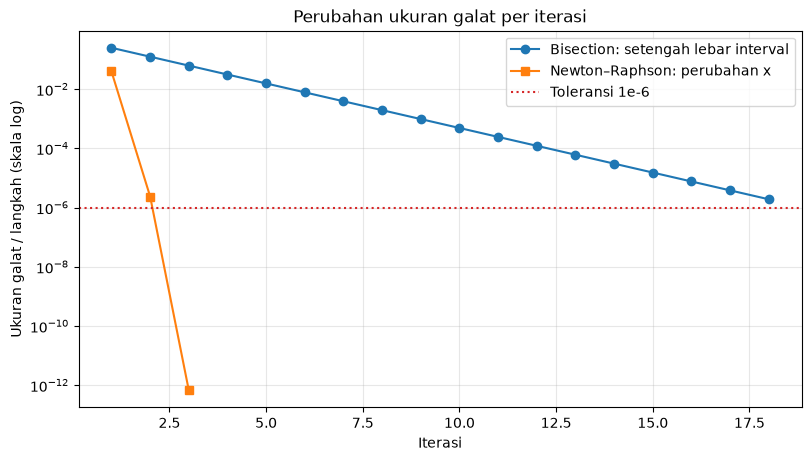

Selisih kedua hasil: 3.702e-07
Residu Bisection |f(x)|: 9.003e-07
Residu Newton     |f(x)|: 0.000e+00


In [35]:
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax.semilogy([r['iter'] for r in riwayat_b], [r['error'] for r in riwayat_b],
            'o-', label='Bisection: setengah lebar interval')
ax.semilogy([r['iter'] for r in riwayat_n], [r['error'] for r in riwayat_n],
            's-', label='Newton–Raphson: perubahan x')
ax.axhline(1e-6, color='tab:red', linestyle=':', label='Toleransi 1e-6')
ax.set(xlabel='Iterasi', ylabel='Ukuran galat / langkah (skala log)',
       title='Perubahan ukuran galat per iterasi')
ax.grid(alpha=0.3, which='both')
ax.legend()
plt.show()

print(f'Selisih kedua hasil: {abs(akar_b - akar_n):.3e}')
print(f'Residu Bisection |f(x)|: {abs(f(akar_b)):.3e}')
print(f'Residu Newton     |f(x)|: {abs(f(akar_n)):.3e}')
